<a href="https://colab.research.google.com/github/Rogerio-mack/Modelos_de_Linguagem_e_Generativos/blob/main/LLM_metrics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Métricas de Modelos LLM (ROUGE, METEOR, BLEU, etc.)**

Diferentemente de tarefas de classificação ou regressão, onde métricas objetivas como acurácia ou MSE são diretas, a qualidade de um texto gerado por LLMs é muitas vezes subjetiva e difícil ser estimada. De fato, até o momento o padrão ouro de métricas de modelos LLM parece ser a **avaliação manual**, que pode capturar nuances como fluência, coerência, factualidade e relevância. No entanto, diversas métricas automáticas foram desenvolvidas para tentar quantificar a similaridade entre o texto gerado por um modelo e um ou mais textos de referência (produzidos por humanos).






## Importância das Métricas

A avaliação dos modelos LLM é importante de diversos casos:

*   **Comparação de Modelos:** Avaliar qual modelo tem melhor desempenho para uma tarefa específica.

>> $\longrightarrow$ Aqui incluem-se tanto a comparação entre modelos pré-treinados como a comparação entre o modelo pré-treinado e eventuais **fine tunnigs do modelo**.

*   **Monitoramento de Progresso:** Acompanhar o avanço do treinamento de um modelo.
*   **Otimização de Hiperparâmetros:** Ajustar parâmetros do modelo para maximizar a qualidade da geração.

As métricas automáticas não substituem, entretanto, completamente a avaliação humana.

>> **$\longrightarrow$ As métricas também não são um critério definitivo e apresentam,  em geral, grande custo para sua avaliação**.


## Métricas Baseadas em Comparação `ROUGE / BLEU / METEOR / BERTScore`

Essas métricas empregam um texto de referência, produzido por um humano, para avaliar os modelos. Existem alguns poucos conjuntos de dados públicos/benchmarks para tarefas como sumarização, tradução e QA em português (há muito mais conjuntos de dados para o inglês), sendo esse um dos gargalos da avaliação de modelos com essas métricas.


### ROUGE (Recall-Oriented Understudy for Gisting Evaluation)

**ROUGE** é a métrica mais amplamente utilizada para avaliar a **qualidade de resumos e outras tarefas de geração de texto onde a sobreposição de conteúdo é importante**. É "recall-oriented" porque mede o quanto do conteúdo do(s) resumo(s) de referência está presente no resumo gerado pelo modelo.

#### Variantes:

*   **ROUGE-N:** Mede a sobreposição de **n-gramas** (sequências contíguas de N palavras) entre o texto gerado e o de referência.
    *   **ROUGE-1:** Sobreposição de unigramas (palavras individuais).
    *   **ROUGE-2:** Sobreposição de bigramas (pares de palavras consecutivas).
    *   Geralmente, quanto maior N, mais a métrica penaliza a ordem das palavras.
  `ROUGE-N = (Número de n-gramas em comum) / (Número de n-gramas no resumo de referência)`

*   **ROUGE-L (Longest Common Subsequence):** Mede a sobreposição da **subsequência comum mais longa** entre o texto gerado e o de referência. Não exige que os n-gramas sejam contíguos, apenas que mantenham a ordem relativa. É mais flexível que ROUGE-N em relação à ordem das palavras.

    `ROUGE-L = LCS(gerado, referência) / len(referência)`

*   **ROUGE-S (Skip-Bigram):** Mede a sobreposição de pares de palavras, permitindo que haja palavras intermediárias ("skip"). Por exemplo, para a frase "o gato preto", os skip-bigramas seriam ("o", "gato"), ("o", "preto") e ("gato", "preto").

ROUGE reporta **Recall**, **Precision** e **F1-score** para cada variante. O F1-score é a média harmônica de Precision e Recall e é o valor mais reportado.

<br>

**(+)** Amplamente aceito, bom para tarefas de sumarização e fácil de interpretar.

**(-)** Foca na sobreposição lexical e pode não capturar fluência ou coerência semântica. É também sensível a sinônimos.

<br>

### Exemplo

ROUGE-1 measures the overlap of individual words (unigrams).

* **Unigrams in R**: {The, quick, brown, fox, jumps, over, the, lazy, dog} (9 total)
* **Unigrams in C**: {The, quick, brown, dog, jumps, on, the, log} (8 total)
* **Overlapping Unigrams**: {The, quick, brown, dog, jumps, the} (6 total)


| Metric | 	Calculation |	Score	| Explanation |
|-|-|-|-|
|Precision | (Overlap in C / Total in C) |	6 / 8 = 0.75	|Three-quarters of the generated words are relevant to the reference. |
| Recall	| (Overlap in C / Total in R) |	6 / 9 ≈ 0.67 |	About two-thirds of the reference words are in the generated text. |
| F1 Score	| 2 * (P * R) / (P + R) |	≈ 0.71 |	A balance of precision and recall. |


Note que,

$$ P = \frac{m}{w_r} $$

$$ R = \frac{m}{w_c} $$

Onde $m$ é o número de unigramas do texto candidato que também são encontrados no texto de referência (uma tradução, um sumário etc.) e $w_{r}$,  $w_{c}$ são respectivamente o número de unigramas no texto de referência e no texto candidato. Em geral isso é medido por frase.



### BLEU (Bilingual Evaluation Understudy)

**BLEU** é uma métrica originalmente desenvolvida para avaliação de **tradução automática**. Mede a precisão da sobreposição de n-gramas entre a tradução gerada e uma ou mais traduções de referência. O BLEU também inclui uma penalidade de brevidade (*brevity penalty*) para evitar que modelos gerem traduções muito curtas para inflar a precisão.

`BLEU = BP * exp(sum(w_n * log(Pn)))`

Onde `BP` é a penalidade de brevidade, `w_n` são os pesos para cada n-grama (geralmente 1/N), e `Pn` é a precisão de n-gramas.

<br>

**(+)** Bom para tarefas de tradução.

**(-)** Não captura similaridade semântica e é menos adequado para tarefas de geração mais criativas como sumarização ou diálogo. Foca apenas na precisão.


### METEOR (Metric for Evaluation of Translation with Explicit Ordering)

**METEOR** é outra métrica para tradução automática que tenta superar algumas limitações do BLEU e ROUGE, focando em um alinhamento mais sofisticado entre as palavras. Ele considera:

*   **Correspondências exatas de palavras.**
*   **Correspondências de stem** (ex: "correr" e "correndo").
*   **Correspondências de sinônimos** (usando WordNet ou similar).
*   **Correspondências de paráfrases.**

Após o alinhamento, calcula uma pontuação baseada em Precision e Recall, com uma penalidade por fragmentação (chunks) para favorecer traduções mais fluentes. METEOR é considerado mais correlacionado com a avaliação humana do que BLEU em algumas tarefas.

<br>

**(+)** Mais robusto a variações de palavras (sinônimos, stems), melhor correlação com julgamento humano.

**(-)** Mais complexo de calcular, ainda foca principalmente na sobreposição lexical.


![image](https://github.com/Rogerio-mack/Modelos_de_Linguagem_e_Generativos/blob/main/figures/metrics_alignment.png?raw=true)

### Exemplo

* **Referência**:
```
o gato     sentado sobre o esteira
```
* **Hipótese**:
```
o gato era sentado sobre o esteira
```

<br>

**Pontuação**

$$ 0.9654={\underset {\text{Fmean}}{0.9836}}\times (1-{\underset {\text{Penalty}}{0.0185}})$$

**Fmédia**

$$ 0,9836=10\times {\underset {\text{Precisão}}{0,8571}}\times {\frac {\overset {\text{Recall}}{1,0000}}{{\underset {\text{Recall}}{1,0000}}+9\times {\underset {\text{Precisão}}{0,8571}}}}$$

Nesta média harmônica, um peso maior é dado para o recall.

**Penalização**

$$ 0,0185=0,5\times {\underset {\text{Fragmentação}}{0,3333^{3}}}$$

A penalização leva em conta a dispersão do conteúdo do texto entre a referência e o texto candidato. Mesmo que o modelo acerte todas as palavras, se elas vierem embaralhadas, fragmentadas ou fora da ordem, a métrica considera isso pior que um texto que agrupa informações de forma parecida com a referência.

**Fragmentação**

$$ 0.3333={\frac {\overset {\text{Chunks}}{2.0}}{\underset {\text{Matches}}{6.0}}}$$

Ver Exemplo de alinhamento (a), 1/3 ok preservando a ordem.

## Cálculo das Métricas em Python

In [1]:
!pip install evaluate rouge_score sacrebleu nltk bert_score moverscore

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 4.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 3.7 MB/s eta 0:00:00
  Created wheel for rouge_score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=8d35cde8374bd1fcf45ddf38e687efaa226540fa36ca5613729725c5a1f36f6e
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
  Created wheel for moverscore: filename=moverscore-1.0.3-py3-none-any.whl size=7950 sha256=9bb25cfee5446867d3bcb19ed0c143f1cbf911cd07becea481fc33bb5f87a784
  Stored in directory: /root/.cache/pip/wheels/76/20/33/fffbeb74a615f13ae51c974da807383935518b3ec821609c02
  Created wheel for typing: fi

In [1]:
import nltk

try:
    nltk.data.find("tokenizers/punkt")
except LookupError:
    nltk.download("punkt")
try:
    nltk.data.find("corpora/wordnet")
except LookupError:
    nltk.download("wordnet")

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


## Avaliando bons textos...

In [24]:
import evaluate
import numpy as np

# Textos de exemplo
predictions = [
    "O gato sentou no tapete.",
    "Eu gosto de comer maçãs.",
    "A casa é grande e bonita.",
    "O cachorro correu rapidamente pela rua."
]
references = [
    ["O gato estava sentado no tapete.", "Um gato sentou no tapete."],
    ["Maçãs são minhas frutas favoritas."],
    ["Uma casa grande e bonita.", "A casa é bonita e grande."],
    ["Um cão correu rápido pela rua."]
]

print("--- Textos de Exemplo ---")
for i in range(len(predictions)):
    print(f"Predição: {predictions[i]}")
    print(f"Referências: {references[i]}\n")

### 1. ROUGE
print("--- Calculando ROUGE ---")
rouge = evaluate.load("rouge")
results_rouge = rouge.compute(predictions=predictions, references=references, use_stemmer=True)
print(results_rouge)

### 2. BLEU
print("\n--- Calculando BLEU ---")
bleu = evaluate.load("bleu")
# BLEU espera referências como uma lista de listas de strings
# Cada item na lista externa é um exemplo, e cada item na lista interna é uma referência para aquele exemplo
# predictions = ["The cat sat on the mat.", "I like to eat apples."]
# references = [["The cat was sitting on the mat.", "A cat sat on the mat."], ["Apples are my favorite fruit."]]

# Ajustando o formato das referências para BLEU
bleu_references = [[ref] if isinstance(ref, str) else ref for ref in references]

results_bleu = bleu.compute(predictions=predictions, references=bleu_references)
print(results_bleu)

### 3. METEOR
print("\n--- Calculando METEOR ---")
meteor = evaluate.load("meteor")
results_meteor = meteor.compute(predictions=predictions, references=references)
print(results_meteor)




--- Textos de Exemplo ---
Predição: O gato sentou no tapete.
Referências: ['O gato estava sentado no tapete.', 'Um gato sentou no tapete.']

Predição: Eu gosto de comer maçãs.
Referências: ['Maçãs são minhas frutas favoritas.']

Predição: A casa é grande e bonita.
Referências: ['Uma casa grande e bonita.', 'A casa é bonita e grande.']

Predição: O cachorro correu rapidamente pela rua.
Referências: ['Um cão correu rápido pela rua.']

--- Calculando ROUGE ---
{'rouge1': np.float64(0.6697802197802198), 'rouge2': np.float64(0.4621212121212121), 'rougeL': np.float64(0.6197802197802199), 'rougeLsum': np.float64(0.6197802197802199)}

--- Calculando BLEU ---
{'bleu': 0.4211813371894875, 'precisions': [0.6923076923076923, 0.5454545454545454, 0.3888888888888889, 0.21428571428571427], 'brevity_penalty': 1.0, 'length_ratio': 1.04, 'translation_length': 26, 'reference_length': 25}

--- Calculando METEOR ---
{'meteor': np.float64(0.5875413022351798)}


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [25]:
print(f'rougeL..: {results_rouge['rougeL']:.2f}')
print(f'bleu....: {results_bleu['bleu']:.2f}')
print(f'meteor..: {results_meteor['meteor']:.2f}')


rougeL..: 0.62
bleu....: 0.42
meteor..: 0.59


## Avaliando maus textos...

In [31]:
import evaluate
import numpy as np

# Textos de exemplo
predictions = [
    "O gato subiu no telhado.",
    "Eu gosto de chupar laranjas.",
    "A casa é não é grande mas até que é bonita.",
    "O cão saiu em disparada pela rua."
]
references = [
    ["O gato estava sentado no tapete.", "Um gato sentou no tapete."],
    ["Maçãs são minhas frutas favoritas."],
    ["Uma casa grande e bonita.", "A casa é bonita e grande."],
    ["Um cão correu rápido pela rua."]
]

print("--- Textos de Exemplo ---")
for i in range(len(predictions)):
    print(f"Predição: {predictions[i]}")
    print(f"Referências: {references[i]}\n")

### 1. ROUGE
print("--- Calculando ROUGE ---")
rouge = evaluate.load("rouge")
results_rouge = rouge.compute(predictions=predictions, references=references, use_stemmer=True)
print(results_rouge)

### 2. BLEU
print("\n--- Calculando BLEU ---")
bleu = evaluate.load("bleu")
# BLEU espera referências como uma lista de listas de strings
# Cada item na lista externa é um exemplo, e cada item na lista interna é uma referência para aquele exemplo
# predictions = ["The cat sat on the mat.", "I like to eat apples."]
# references = [["The cat was sitting on the mat.", "A cat sat on the mat."], ["Apples are my favorite fruit."]]

# Ajustando o formato das referências para BLEU
bleu_references = [[ref] if isinstance(ref, str) else ref for ref in references]

results_bleu = bleu.compute(predictions=predictions, references=bleu_references)
print(results_bleu)

### 3. METEOR
print("\n--- Calculando METEOR ---")
meteor = evaluate.load("meteor")
results_meteor = meteor.compute(predictions=predictions, references=references)
print(results_meteor)




--- Textos de Exemplo ---
Predição: O gato subiu no telhado.
Referências: ['O gato estava sentado no tapete.', 'Um gato sentou no tapete.']

Predição: Eu gosto de chupar laranjas.
Referências: ['Maçãs são minhas frutas favoritas.']

Predição: A casa é não é grande mas até que é bonita.
Referências: ['Uma casa grande e bonita.', 'A casa é bonita e grande.']

Predição: O cão saiu em disparada pela rua.
Referências: ['Um cão correu rápido pela rua.']

--- Calculando ROUGE ---
{'rouge1': np.float64(0.4042207792207792), 'rouge2': np.float64(0.16865079365079366), 'rougeL': np.float64(0.3685064935064935), 'rougeLsum': np.float64(0.3685064935064935)}

--- Calculando BLEU ---
{'bleu': 0.0, 'precisions': [0.46875, 0.25, 0.08333333333333333, 0.0], 'brevity_penalty': 1.0, 'length_ratio': 1.28, 'translation_length': 32, 'reference_length': 25}

--- Calculando METEOR ---
{'meteor': np.float64(0.43760284128280147)}


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [9]:
print(f'rougeL..: {results_rouge['rougeL']:.2f}')
print(f'bleu....: {results_bleu['bleu']:.2f}')
print(f'meteor..: {results_meteor['meteor']:.2f}')

rougeL..: 0.37
bleu....: 0.00
meteor..: 0.44


## Baseados em Comparação de Embeddings

### BERTScore

**BERTScore** é uma métrica mais moderna que utiliza **embeddings contextuais** de modelos pré-treinados (como BERT) para avaliar a similaridade semântica entre o texto gerado e o de referência. Em vez de comparar n-gramas exatos, ele calcula a similaridade (cosseno) entre os embeddings de cada token no texto gerado e os embeddings de cada token no texto de referência.

Ele então usa um algoritmo de emparelhamento (matching) para encontrar a melhor correspondência para cada token e calcula Precision, Recall e F1-score com base nessas similaridades.

<br>

**(+)** Captura similaridade semântica, melhor correlação com julgamento humano do que métricas baseadas em n-gramas, mais robusto a paráfrases e sinônimos.

**(-)** Mais lento para calcular, requer um modelo de embeddings, pode ser influenciado pelo viés do modelo de embeddings.



In [13]:
import evaluate
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

In [26]:
# Textos de exemplo
predictions = [
    "O gato sentou no tapete.",
    "Eu gosto de comer maçãs.",
    "A casa é grande e bonita.",
    "O cachorro correu rapidamente pela rua."
]
references = [
    ["O gato estava sentado no tapete.", "Um gato sentou no tapete."],
    ["Maçãs são minhas frutas favoritas."],
    ["Uma casa grande e bonita.", "A casa é bonita e grande."],
    ["Um cão correu rápido pela rua."]
]

### 4. BERTScore
print("\n--- Calculando BERTScore ---")
bertscore = evaluate.load("bertscore")


--- Calculando BERTScore ---


In [27]:
results_bertscore = bertscore.compute(predictions=predictions, references=references, lang="pt", model_type="bert-base-multilingual-cased", num_layers=12, use_fast_tokenizer=False)
# BERTScore retorna Precision, Recall e F1 para cada exemplo, e as médias
print(results_bertscore)
print('BERTScore f1 mean = ',np.mean(results_bertscore['f1']))

print('\n\n\n')
print(f'bertscore: {np.mean(results_bertscore["f1"]):.2f}')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


{'precision': [0.894424319267273, 0.5311468839645386, 0.9822477102279663, 0.7538532018661499], 'recall': [0.894424319267273, 0.5258379578590393, 0.9822477102279663, 0.7793257832527161], 'f1': [0.894424319267273, 0.5284790992736816, 0.9822477102279663, 0.766377866268158], 'hashcode': 'bert-base-multilingual-cased_L12_no-idf_version=0.3.12(hug_trans=5.0.0)'}
BERTScore f1 mean =  0.7928822487592697




bertscore: 0.79


### Reexecute os casos bons!

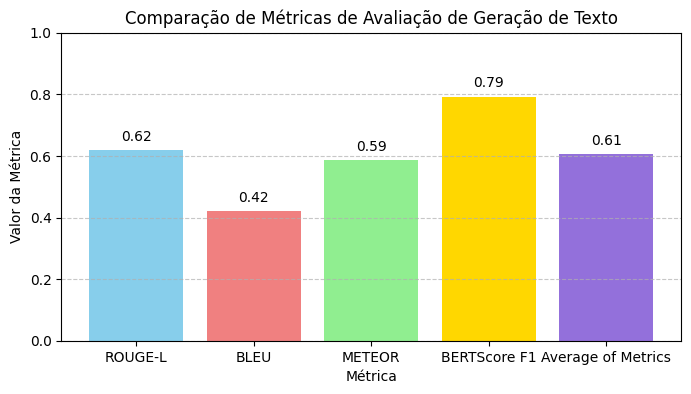

In [28]:
import matplotlib.pyplot as plt
import numpy as np

# Define the metrics and their values
metrics = {
    'ROUGE-L': results_rouge['rougeL'],
    'BLEU': results_bleu['bleu'],
    'METEOR': results_meteor['meteor'],
    'BERTScore F1': np.mean(results_bertscore['f1'])
}

metric_names = list(metrics.keys())
metric_values = list(metrics.values())

# Calculate the average of the existing metrics
average_of_metrics = np.mean(metric_values)

# Add the average metric to the lists for plotting
metric_names.append('Average of Metrics')
metric_values.append(average_of_metrics)

# Define colors for each bar, including the new average bar
colors = ['skyblue', 'lightcoral', 'lightgreen', 'gold', 'mediumpurple']

# Create the bar chart
plt.figure(figsize=(8, 4))
plt.bar(metric_names, metric_values, color=colors)

# Add titles and labels
plt.title('Comparação de Métricas de Avaliação de Geração de Texto')
plt.xlabel('Métrica')
plt.ylabel('Valor da Métrica')
plt.ylim(0, 1) # Metrics usually range from 0 to 1

# Add value labels on top of each bar
for i, value in enumerate(metric_values):
    plt.text(i, value + 0.02, f'{value:.2f}', ha='center', va='bottom')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


### Casos maus... reeexecute

In [30]:
results_bertscore = bertscore.compute(predictions=predictions, references=references, lang="pt", model_type="bert-base-multilingual-cased", num_layers=12, use_fast_tokenizer=False)
# BERTScore retorna Precision, Recall e F1 para cada exemplo, e as médias
print(results_bertscore)
print('BERTScore f1 mean = ',np.mean(results_bertscore['f1']))

print('\n\n\n')
print(f'bertscore: {np.mean(results_bertscore["f1"]):.2f}')

{'precision': [0.7459286451339722, 0.4159512519836426, 0.7387966513633728, 0.7206104397773743], 'recall': [0.7392961978912354, 0.429107666015625, 0.7950674295425415, 0.7482883930206299], 'f1': [0.7425976395606995, 0.4224270284175873, 0.7658998966217041, 0.7341887354850769], 'hashcode': 'bert-base-multilingual-cased_L12_no-idf_version=0.3.12(hug_trans=5.0.0)'}
BERTScore f1 mean =  0.6662783250212669




bertscore: 0.67


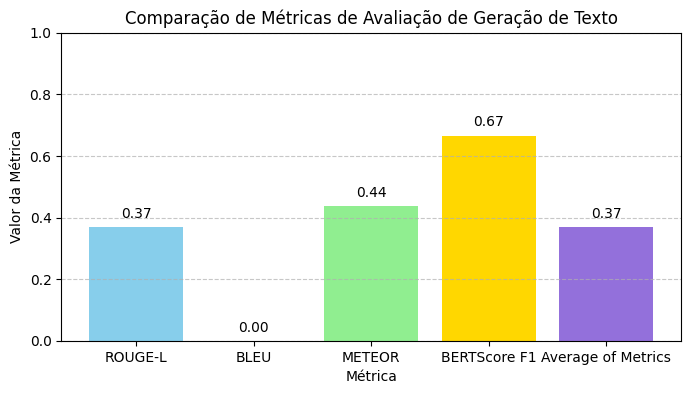

In [32]:
import matplotlib.pyplot as plt
import numpy as np

# Define the metrics and their values
metrics = {
    'ROUGE-L': results_rouge['rougeL'],
    'BLEU': results_bleu['bleu'],
    'METEOR': results_meteor['meteor'],
    'BERTScore F1': np.mean(results_bertscore['f1'])
}

metric_names = list(metrics.keys())
metric_values = list(metrics.values())

# Calculate the average of the existing metrics
average_of_metrics = np.mean(metric_values)

# Add the average metric to the lists for plotting
metric_names.append('Average of Metrics')
metric_values.append(average_of_metrics)

# Define colors for each bar, including the new average bar
colors = ['skyblue', 'lightcoral', 'lightgreen', 'gold', 'mediumpurple']

# Create the bar chart
plt.figure(figsize=(8, 4))
plt.bar(metric_names, metric_values, color=colors)

# Add titles and labels
plt.title('Comparação de Métricas de Avaliação de Geração de Texto')
plt.xlabel('Métrica')
plt.ylabel('Valor da Métrica')
plt.ylim(0, 1) # Metrics usually range from 0 to 1

# Add value labels on top of each bar
for i, value in enumerate(metric_values):
    plt.text(i, value + 0.02, f'{value:.2f}', ha='center', va='bottom')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


### MoverScore

**MoverScore** é outra métrica baseada em embeddings que utiliza a **distância de movimentação da terra (Earth Mover's Distance - EMD)** para medir a similaridade entre dois textos. A EMD calcula o custo mínimo para transformar uma distribuição de "massa" (palavras) em outra. Em MoverScore, as "massas" são os embeddings de palavras, e o custo de mover uma palavra para outra é a distância entre seus embeddings.

Ele é capaz de capturar a similaridade entre frases que não compartilham palavras em comum, mas que expressam o mesmo significado.

<br>

**(-)** Muito bom em capturar similaridade semântica, robusto a paráfrases, pode lidar com textos sem sobreposição lexical.

**(+)** Muito mais complexo e lento para calcular e requer embeddings de palavras.


![image](https://github.com/Rogerio-mack/Modelos_de_Linguagem_e_Generativos/blob/main/figures/EMD.bin?raw=true)

Veja que é um NP problema, havendo para 8 casos $8! = 40.320$ possibibilidades...

## Perplexidade

A perplexidade (PPL) é uma  métrica clássica para avaliar modelos de linguagem baseados em probabilidade, muito usada antes do surgimento dos LLMs (Fred Jelinek et al. **Perplexity—a measure of the difficulty of speech recognition tasks.** The Journal of the
Acoustical Society of America 62.S1 (**1977**): S63). **Ela é uma métrica intríseca dos modelos e, por isso, não requer um conjunto de dados de referência**. Ela mede o quão "surpreso" um modelo fica diante de um conjunto de textos, e quanto menor a perplexidade, melhor o modelo está modelando a distribuição daquele texto.

O cálculo é dado por

$$PPL=exp(−\frac{1}{N}\sum_{i=1}^N \ln p(w_i ∣ w_{<i}​))$$

Que é a Log-verossimilhança média de todas as palavras previstas em um dado conjunto de teste.

> PPL = 10 → o modelo “escolhe” entre 10 opções prováveis em média.

> PPL = 100 → está muito mais incerto.

É assim uma medida de "confusão" e quanto menor menos o modelo está confuso.

![image](https://github.com/Rogerio-mack/Modelos_de_Linguagem_e_Generativos/blob/main/figures/perplexity.png?raw=true)

<br>

**(+)** Fácil de calcular e não requer um conjunto de dados de referência.

**(-)** Limitado: Não mede qualidade de respostas e não avalia raciocínio. Avaliamos LLMs como modelos de linguagem, não como chatbots ou outra tarefa. Comparamos modelos somente com o mesmo vocabulário (tokenizer) e objetivo.

Também se aplica a modelos Autorregressivos como GPT, Llama, Claude (dependendo do uso), Gemini (se for causal), mas não a Modelos Mascarados como BERT e DeepSeek, que buscam a predição do entorno de uma palavra.

### Exemplo

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

In [ ]:
# Load pre-trained GPT-2 model and tokenizer
model_name = "gpt2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)

# Assign the EOS token as the padding token
tokenizer.pad_token = tokenizer.eos_token

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

loading configuration file config.json from cache at /root/.cache/huggingface/hub/models--gpt2/snapshots/607a30d783dfa663caf39e06633721c8d4cfcd7e/config.json
Model config GPT2Config {
  "activation_function": "gelu_new",
  "architectures": [
    "GPT2LMHeadModel"
  ],
  "attn_pdrop": 0.1,
  "bos_token_id": 50256,
  "embd_pdrop": 0.1,
  "eos_token_id": 50256,
  "initializer_range": 0.02,
  "layer_norm_epsilon": 1e-05,
  "model_type": "gpt2",
  "n_ctx": 1024,
  "n_embd": 768,
  "n_head": 12,
  "n_inner": null,
  "n_layer": 12,
  "n_positions": 1024,
  "reorder_and_upcast_attn": false,
  "resid_pdrop": 0.1,
  "scale_attn_by_inverse_layer_idx": false,
  "scale_attn_weights": true,
  "summary_activation": null,
  "summary_first_dropout": 0.1,
  "summary_proj_to_labels": true,
  "summary_type": "cls_index",
  "summary_use_proj": true,
  "task_specific_params": {
    "text-generation": {
      "do_sample": true,
      "max_length": 50
    }
  },
  "transformers_version": "4.57.2",
  "use_cach

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

loading file vocab.json from cache at /root/.cache/huggingface/hub/models--gpt2/snapshots/607a30d783dfa663caf39e06633721c8d4cfcd7e/vocab.json
loading file merges.txt from cache at /root/.cache/huggingface/hub/models--gpt2/snapshots/607a30d783dfa663caf39e06633721c8d4cfcd7e/merges.txt
loading file tokenizer.json from cache at /root/.cache/huggingface/hub/models--gpt2/snapshots/607a30d783dfa663caf39e06633721c8d4cfcd7e/tokenizer.json
loading file added_tokens.json from cache at None
loading file special_tokens_map.json from cache at None
loading file tokenizer_config.json from cache at /root/.cache/huggingface/hub/models--gpt2/snapshots/607a30d783dfa663caf39e06633721c8d4cfcd7e/tokenizer_config.json
loading file chat_template.jinja from cache at None
loading configuration file config.json from cache at /root/.cache/huggingface/hub/models--gpt2/snapshots/607a30d783dfa663caf39e06633721c8d4cfcd7e/config.json
Model config GPT2Config {
  "activation_function": "gelu_new",
  "architectures": [
  

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

loading weights file model.safetensors from cache at /root/.cache/huggingface/hub/models--gpt2/snapshots/607a30d783dfa663caf39e06633721c8d4cfcd7e/model.safetensors
Generate config GenerationConfig {
  "bos_token_id": 50256,
  "eos_token_id": 50256
}



generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

loading configuration file generation_config.json from cache at /root/.cache/huggingface/hub/models--gpt2/snapshots/607a30d783dfa663caf39e06633721c8d4cfcd7e/generation_config.json
Generate config GenerationConfig {
  "bos_token_id": 50256,
  "eos_token_id": 50256
}

Could not locate the custom_generate/generate.py inside gpt2.


In [ ]:
def compute_perplexity_for_batch(input_texts):
    inputs = tokenizer(
        input_texts, return_tensors="pt", padding=True, truncation=True
    )

    input_ids = inputs["input_ids"]
    attention_mask = inputs["attention_mask"]

    with torch.no_grad():
        outputs = model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits

    shift_logits = logits[:, :-1, :]
    shift_labels = input_ids[:, 1:]

    log_probs = torch.nn.functional.log_softmax(shift_logits, dim=-1)
    target_log_probs = log_probs.gather(dim=-1, index=shift_labels.unsqueeze(-1)).squeeze(-1)
    target_log_probs = target_log_probs * attention_mask[:, 1:].to(log_probs.dtype)
    negative_log_likelihood = -target_log_probs.sum(dim=-1) / attention_mask[:, 1:].sum(dim=-1)
    perplexities = torch.exp(negative_log_likelihood)
    mean_perplexity_score = torch.mean(perplexities)

    return {
        "perplexities": perplexities.tolist(),
        "mean_perplexity": mean_perplexity_score.item()
    }

In [ ]:
example_texts = [
    "Once upon a time, there was a brave knight.",
    "In a galaxy far, far away, a new adventure began."
]

# Compute perplexity scores for the batch of input texts
results = compute_perplexity_for_batch(example_texts)
print(f"Perplexity scores for each text: {results['perplexities']}")
print(f"Mean perplexity score: {results['mean_perplexity']}")

Perplexity scores for each text: [25.6070556640625, 18.611244201660156]
Mean perplexity score: 22.109149932861328


### Limitações das Métricas Tradicionais e Métricas Humanas: O Padrão Ouro

Métricas como ROUGE ,BLEU e METEOR são amplamente utilizadas para tarefas como sumarização e tradução automática. Elas medem a sobreposição de n-gramas entre o texto gerado e um ou mais textos de referência. No entanto elas apresentam limitações significativas:

*   **Foco em Correspondência de Palavras:** Não capturam similaridade semântica. Um texto pode ser semanticamente idêntico, mas usar palavras diferentes, resultando em uma pontuação baixa.
*   **Necessidade de Referências Múltiplas:** Exigem um ou mais textos de referência "perfeitos", o que é difícil e caro de obter para respostas generativas e abertas.
*   **Ignoram Coerência e Fluência:** Um texto com alta sobreposição de palavras pode ainda ser incoerente ou não fluente.
*   **Não Avaliam Factualidade ou Segurança:** Não conseguem detectar alucinações, vieses ou toxicidade.

A avaliação humana é frequentemente considerada o "padrão ouro" para LLMs, pois os humanos podem julgar nuances como coerência, factualidade, utilidade e segurança. As abordagens da avaliação humana incluem:

1.  **Avaliação por Especialistas:** Avaliadores treinados (linguistas, especialistas no domínio) fornecem feedback detalhado sobre a qualidade da resposta. É caro, mas oferece insights profundos.
2.  **Crowdsourcing:** Utiliza plataformas, como Amazon Mechanical Turk, para coletar avaliações de um grande número de pessoas. Mais escalável e econômico, mas pode ter variância na qualidade.
3.  **A/B Testing:** Compara duas versões de um LLM (ou prompt) em um ambiente de produção, medindo métricas de engajamento do usuário, satisfação ou conclusão de tarefas. É a forma mais realista de avaliação de utilidade.
4.  **Comparação Lado a Lado:** Apresenta duas respostas (de diferentes modelos ou prompts) ao avaliador e pede que escolha a melhor, ou as classifique. É uma forma eficaz de capturar preferências.


# Você pode avaliar um LLM...

Try https://lmarena.ai/